# Линейная регрессия на собственном датасете

## Содержание

0. Загрузка своего датасета (Kaggle)
1. Быстрый разведочный анализ (EDA) на новом датасете
2. Подготовка данных к регрессии
3. Обучение линейной регрессии
4. Оценка качества модели (метрики)
5. Интерпретация коэффициентов
6. Практикум

Это занятие продолжает пайплайн из первого блокнота (очистка → EDA → модель), только теперь вы применяете его к **своему** датасету с Kaggle. Если в вашем датасете чего-то из первого занятия ещё не хватает (пропуски, дубликаты, аномалии) — сначала доведите данные до состояния `df_clean`, как на первом занятии, и только потом переходите к регрессии.

## 0. Загрузка своего датасета

Перед началом убедитесь, что:
- датасет табличный (не картинки и не текст);
- в нём есть понятная **числовая** целевая переменная (то, что мы будем предсказывать) — например, цена, рейтинг, доход, время;
- строк не менее ~1000.

Скачайте `.csv` с Kaggle и положите его рядом с блокнотом (или загрузите через `files.upload()` в Google Colab).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

FILE_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(FILE_PATH)
print("Размер таблицы:", df.shape)
df.head()

Размер таблицы: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Задача 0.**
Опишите словами в ячейке ниже (markdown):
- что предсказывает ваша модель (какая целевая переменная и в каких единицах измеряется);
- откуда взяты данные (ссылка на Kaggle);
- какая бизнес-задача стоит за этим прогнозом (кому и зачем нужен этот прогноз).

**Ваш ответ:**

1.  TotalCharges - суммарную сумму, которую клиент заплатил телеком-компании за всё время пользования услугами
2. Ссылка: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
3. Бизнес задача: оценка Lifetime Value клиента.  сколько денег он принесёт компании за всё время.


## 1. Быстрый разведочный анализ (EDA)

Прежде чем строить модель, ещё раз убедитесь, что данные в порядке — коротко повторяем шаги первого занятия.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


преобразуем 

In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [7]:
display(df.describe())
print("Пропуски по столбцам:")
print(df.isna().sum())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Пропуски по столбцам:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


**Задача 1.**
Если в данных остались пропуски или дубликаты — обработайте их (как на первом занятии) и сохраните результат в `df_clean`. Если данные уже чистые — просто продублируйте `df` в `df_clean`.

In [ ]:

df["TotalCharges"] = df["TotalCharges"].fillna(0)

# 3. Проверка дубликатов
print("Полных дубликатов строк:", df.duplicated().sum())
print("Дубликатов по customerID:", df.duplicated(subset=["customerID"]).sum())

df_clean = df.drop_duplicates().copy()
df_clean = df_clean.drop(columns=["customerID"])

print("\nРазмер df_clean:", df_clean.shape)

Полных дубликатов строк: 0
Дубликатов по customerID: 0

Размер df_clean: (7043, 20)


**Задача 2.**
Постройте гистограмму распределения вашей целевой переменной. Опишите в ячейке «Вывод», нормальное ли у неё распределение, есть ли перекос (skew) или явные выбросы.

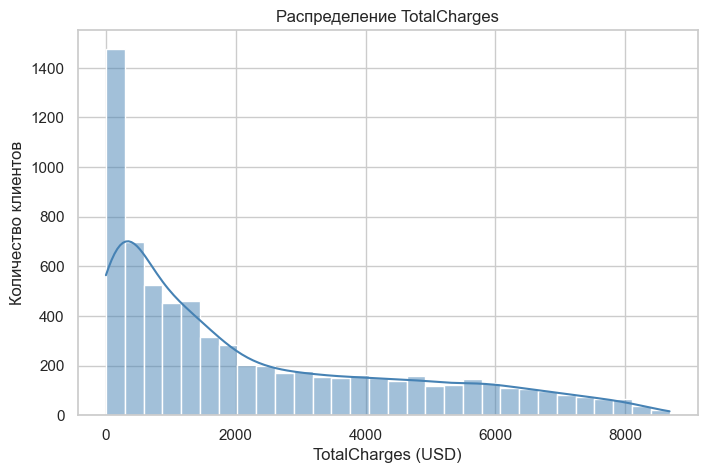

Skew:      0.96
Kurtosis:  -0.23
Среднее:   2280
Медиана:   1395
Мин:       0
Макс:      8685


In [11]:
TARGET = "TotalCharges"

# Гистограмма
sns.histplot(df_clean[TARGET], bins=30, kde=True, color="steelblue")
plt.title("Распределение TotalCharges")
plt.xlabel("TotalCharges (USD)")
plt.ylabel("Количество клиентов")
plt.show()

# Числовые характеристики распределения
print(f"Skew:      {df_clean[TARGET].skew():.2f}")
print(f"Kurtosis:  {df_clean[TARGET].kurtosis():.2f}")
print(f"Среднее:   {df_clean[TARGET].mean():.0f}")
print(f"Медиана:   {df_clean[TARGET].median():.0f}")
print(f"Мин:       {df_clean[TARGET].min():.0f}")
print(f"Макс:      {df_clean[TARGET].max():.0f}")

**Вывод:**
Skew=0.96 говорит о умеренном правом скосе.
Отрицательный куртозис: распределение плосковершинное с длинным правым хвостом.
Среднее значительно больше медианы, тем самым подтверждая правый скос.

## 2. Подготовка данных к регрессии

Модели линейной регрессии нужны **числа** на входе. Категориальные признаки (текстовые столбцы) нужно закодировать, например через `pd.get_dummies()`. Дальше данные делятся на обучающую и тестовую выборки — модель обучается на одной части и проверяется на другой, которую не видела.

In [13]:
from sklearn.model_selection import train_test_split

TARGET = "TotalCharges"  
USE_LOG = True   # логарифмируем из-за скошенности

# Кодируем категориальные признаки
if USE_LOG:
    df_clean["log_target"] = np.log1p(df_clean[TARGET])
    y = df_clean["log_target"]
else:
    y = df_clean[TARGET]
    
X = df_clean.drop(columns=[TARGET, "log_target"], errors="ignore")
X = pd.get_dummies(X, drop_first=True)



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)
print("Признаков всего:  ", X.shape[1])


Обучающая выборка: (5634, 30)
Тестовая выборка: (1409, 30)
Признаков всего:   30


**Задача 3.**
Проверьте, не остались ли в `X` нечисловые столбцы (например, даты как объекты) после `get_dummies()`. Если остались — либо удалите их, либо превратите в числовые признаки (например, извлеките месяц/год из даты, как на первом занятии).

In [14]:
# Проверяем, какие типы данных остались в X
print("Типы данных в X:")
print(X.dtypes.value_counts())

# Ищем нечисловые столбцы
non_numeric = X.select_dtypes(include=["object", "datetime", "category"]).columns.tolist()

if non_numeric:
    print("\nНечисловые столбцы найдены:")
    print(non_numeric)
else:
    print("\nНечисловых столбцов нет — все признаки числовые.")

# Дополнительная проверка: NaN и inf
print("\nNaN в X_train:", X_train.isna().sum().sum())
print("NaN в X_test: ", X_test.isna().sum().sum())
print("inf в X_train:", np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum())
print("inf в X_test: ", np.isinf(X_test.select_dtypes(include=[np.number])).sum().sum())

Типы данных в X:
bool       27
int64       2
float64     1
Name: count, dtype: int64

Нечисловых столбцов нет — все признаки числовые.

NaN в X_train: 0
NaN в X_test:  0
inf в X_train: 0
inf в X_test:  0


## 3. Обучение линейной регрессии

### Математический аппарат

Линейная регрессия ищет такие коэффициенты $\beta$, при которых предсказание

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$

как можно ближе к реальному значению $y$ — модель минимизирует сумму квадратов ошибок:

$$\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 \rightarrow \min$$

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## 4. Оценка качества модели

Одной метрики обычно недостаточно — они показывают разные стороны качества модели.

**MAE (Mean Absolute Error)** — средняя абсолютная ошибка, в тех же единицах, что и целевая переменная. Легко интерпретируется («в среднем ошибаемся на N рублей»), но одинаково штрафует и маленькие, и большие ошибки:

$$MAE = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|$$

**MSE (Mean Squared Error)** — среднеквадратичная ошибка. Из-за возведения в квадрат сильнее штрафует большие ошибки (выбросы в предсказаниях «стоят дороже»):

$$MSE = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**RMSE (Root Mean Squared Error)** — корень из MSE. В отличие от MSE, измеряется в тех же единицах, что и целевая переменная, поэтому удобнее для интерпретации:

$$RMSE = \sqrt{MSE}$$

**MAPE (Mean Absolute Percentage Error)** — средняя ошибка в процентах от реального значения. Удобна, когда нужно сравнивать качество модели на данных с разным масштабом (например, между регионами с разными ценами):

$$MAPE = \frac{100\%}{n}\sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

*Осторожно: MAPE «ломается», если среди значений $y_i$ встречаются нули или значения, близкие к нулю.*

**R² (коэффициент детерминации)** — доля дисперсии целевой переменной, объяснённая моделью:

$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

- $R^2 = 1$ — идеальное предсказание;
- $R^2 = 0$ — модель не лучше, чем просто предсказывать среднее значение $\bar{y}$ для всех объектов;
- $R^2 < 0$ — модель хуже, чем предсказание средним (бывает на тестовой выборке при переобучении).

**Как выбирать метрику:** если в задаче важны единицы измерения и крупные ошибки критичны (например, прогноз бюджета) — смотрите на RMSE; если нужна устойчивость к выбросам — на MAE; если нужно сравнивать модели между разными масштабами данных — на MAPE; R² полезен для быстрой оценки «на глаз», но сам по себе не заменяет остальные метрики.

## Для логорифмической величины

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# MAPE считаем вручную, отбросив нулевые значения y_test
mask = y_test != 0
mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.1f}%")
print(f"R2:   {r2:.3f}")

MAE:  0.50
MSE:  0.39
RMSE: 0.63
MAPE: 8.9%
R2:   0.845


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Обратное преобразование из логарифма в доллары
y_pred_dollars = np.expm1(y_pred)
y_test_dollars = np.expm1(y_test)

mae = mean_absolute_error(y_test_dollars, y_pred_dollars)
mse = mean_squared_error(y_test_dollars, y_pred_dollars)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_dollars, y_pred_dollars)

mask = y_test_dollars != 0
mape = np.mean(np.abs((y_test_dollars[mask] - y_pred_dollars[mask]) / y_test_dollars[mask])) * 100

print(f"MAE:  {mae:,.2f} $")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f} $")
print(f"MAPE: {mape:.1f}%")
print(f"R2:   {r2:.3f}")

MAE:  934.77 $
MSE:  3,156,755.28
RMSE: 1,776.73 $
MAPE: 63.7%
R2:   0.393


**Задача 4.**
Постройте scatter-график: по оси X — реальные значения `y_test`, по оси Y — предсказанные `y_pred`. Добавьте диагональную линию (идеальное предсказание). Опишите в «Выводе», где модель ошибается больше всего.

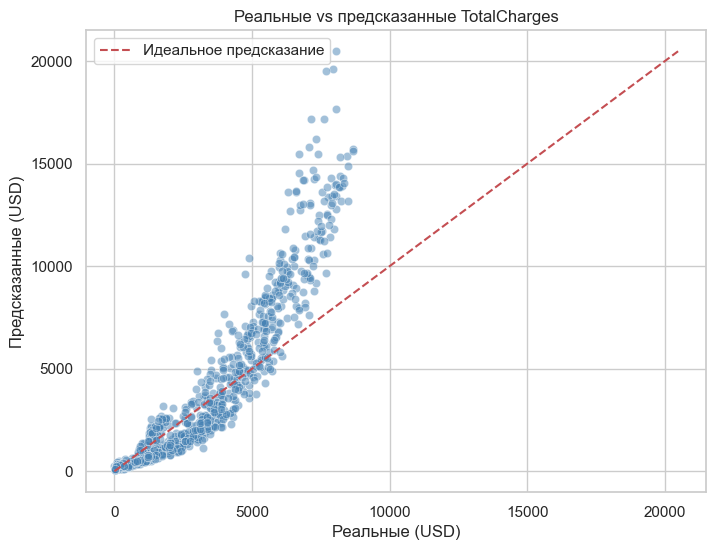

In [22]:
## не логорифмируя 
y_test_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_pred)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_dollars, y=y_pred_dollars, alpha=0.5, color="steelblue")

# Диагональ идеального предсказания
lims = [
    min(y_test_dollars.min(), y_pred_dollars.min()),
    max(y_test_dollars.max(), y_pred_dollars.max()),
]
plt.plot(lims, lims, "r--", label="Идеальное предсказание")

plt.title("Реальные vs предсказанные TotalCharges")
plt.xlabel("Реальные (USD)")
plt.ylabel("Предсказанные (USD)")
plt.legend()
plt.show()

**Вывод:**

Модель улавливает общий тренд, но систематически занижает высокие значения и завышает низкие. разброс ошибок растет вместе с ростом целевой переменной. Пазброс ошибок растет вместе с ростом целевой переменной.

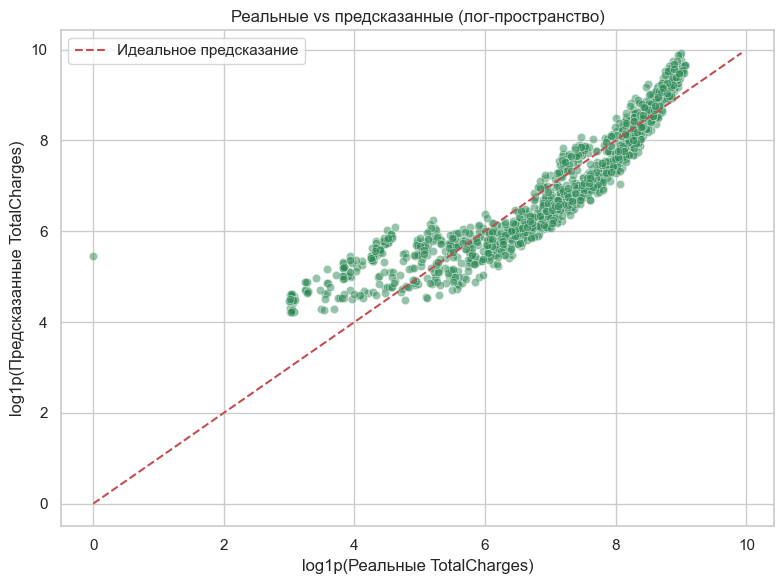

In [25]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color="seagreen")

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Идеальное предсказание")

plt.title("Реальные vs предсказанные (лог-пространство)")
plt.xlabel("log1p(Реальные TotalCharges)")
plt.ylabel("log1p(Предсказанные TotalCharges)")
plt.legend()
plt.tight_layout()
plt.show()

**Задача 4.1.**
Сравните MAE и RMSE вашей модели. Если RMSE заметно больше MAE — это признак того, что на некоторых объектах модель ошибается особенно сильно (выбросы в ошибках). Найдите 5 объектов тестовой выборки с наибольшей ошибкой предсказания и опишите, что их объединяет.

In [26]:
import numpy as np
import pandas as pd

# Ошибки на тестовой выборке (в логах и в долларах)
errors_log = np.abs(y_test - y_pred)
errors_usd = np.abs(np.expm1(y_test) - np.expm1(y_pred))

# Сводная таблица по всем объектам теста
results = pd.DataFrame({
    'real_log': y_test.values,
    'pred_log': y_pred,
    'real_usd': np.expm1(y_test.values),
    'pred_usd': np.expm1(y_pred),
    'error_log': errors_log.values,
    'error_usd': errors_usd.values,
}, index=y_test.index)

# Топ-5 объектов с наибольшей ошибкой
top5 = results.sort_values('error_usd', ascending=False).head(5)
print("Топ-5 объектов с наибольшей ошибкой (в долларах):")
print(top5.round(2))

Топ-5 объектов с наибольшей ошибкой (в долларах):
      real_log  pred_log  real_usd  pred_usd  error_log  error_usd
3820      8.99      9.93   8061.50  20472.61       0.93   12411.11
3886      8.95      9.88   7677.40  19513.03       0.93   11835.63
4864      8.98      9.88   7953.25  19631.44       0.90   11678.19
4824      8.87      9.75   7133.10  17183.87       0.88   10050.77
3299      8.99      9.78   8035.95  17650.03       0.79    9614.08


**Вывод:**

_..._

## 5. Интерпретация коэффициентов

Коэффициенты линейной регрессии показывают, как меняется прогноз при изменении признака на единицу (при неизменных остальных).

In [23]:
coefficients = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
coefficients.head(10)

Contract_Two year                      -0.331587
Churn_Yes                              -0.246741
InternetService_Fiber optic             0.143073
MultipleLines_Yes                       0.126560
StreamingMovies_Yes                     0.099119
PaymentMethod_Mailed check             -0.091976
StreamingTV_Yes                         0.083872
Contract_One year                       0.077493
DeviceProtection_No internet service   -0.071135
InternetService_No                     -0.071135
dtype: float64

**Задача 5.**
Назовите 3 признака с наибольшим по модулю коэффициентом. Дают ли они интуитивно понятный результат с точки зрения вашей предметной области, или что-то выглядит подозрительно (см. P.S. в конце блокнота про мультиколлинеарность)?

**Ваш ответ:**

_..._

## 6. Практикум

**Задание 6.1.** Обучите вторую модель — `LinearRegression`, но на другом наборе признаков (например, уберите 2-3 признака с наименьшей значимостью, судя по коэффициентам). Сравните все метрики (MAE/RMSE/MAPE/R²) с исходной моделью.

**Вывод:**

_..._

**Задание 6.2.** Постройте гистограмму остатков (`y_test - y_pred`). В идеале остатки должны быть распределены симметрично вокруг нуля. Опишите, что видите на графике.

**Вывод:**

_..._

**Задание 6.3.** Постройте scatter-график остатков (`y_test - y_pred`) в зависимости от предсказанных значений `y_pred`. Если точки образуют явный «веер» или дугу (а не случайное облако вокруг нуля) — это признак того, что модель не улавливает нелинейную зависимость в данных. Опишите, что видите.

**Вывод:**

_..._

**Задание 6.4.** Посчитайте матрицу корреляций между числовыми признаками в `X_train` (`X_train.corr()`) и визуализируйте её через `sns.heatmap()`. Найдите пары признаков с корреляцией выше 0.8 по модулю — это кандидаты на мультиколлинеарность (см. P.S. ниже).

**Вывод:**

_..._

**Задание 6.5.** Попробуйте обучить модель только на 3-5 признаках, которые вы считаете наиболее важными по смыслу задачи (не по коэффициентам, а по своей экспертной оценке). Сравните метрики с полной моделью — сильно ли просела точность при сильном сокращении числа признаков?

**Вывод:**

_..._

**Задание 6.6. Итоговое резюме.**
В 5-7 предложениях опишите: какую задачу решала модель, насколько хорошо она справилась (с опорой на все метрики, а не только на R²), какие признаки оказались важнее всего, обнаружили ли вы мультиколлинеарность, и что бы вы попробовали улучшить в следующей итерации (новые признаки, другая модель, больше данных).

**Резюме:**

_..._

---

## P.S. Что такое мультиколлинеарность

**Мультиколлинеарность** — это ситуация, когда два (или больше) признака в данных сильно коррелируют друг с другом, то есть фактически несут одну и ту же информацию. Например, «площадь квартиры в м²» и «количество комнат» обычно сильно связаны между собой: чем больше комнат, тем больше площадь.

**Почему это проблема для линейной регрессии.** Модель пытается «разделить» вклад каждого признака в прогноз через отдельный коэффициент. Если два признака почти дублируют друг друга, модели становится сложно понять, какому из них приписать влияние на целевую переменную — коэффициенты становятся нестабильными: небольшое изменение данных (например, добавили несколько новых строк) может резко изменить значения коэффициентов, а иногда даже поменять их знак на противоположный. При этом само качество прогноза (метрики MAE/RMSE/R² на тесте) может почти не пострадать — страдает именно **интерпретируемость** модели.

**Как заметить.** Матрица корреляций между признаками (задание 6.4) — самый простой способ. Более строгий инструмент — **VIF (Variance Inflation Factor)**, который показывает, насколько дисперсия коэффициента конкретного признака увеличена из-за его связи с остальными признаками:

$$VIF_j = \frac{1}{1 - R_j^2}$$

где $R_j^2$ — коэффициент детерминации регрессии $j$-го признака на все остальные признаки. Обычно считается, что $VIF > 5-10$ указывает на существенную мультиколлинеарность.

**Что с этим делать.** Убрать один из пары сильно коррелирующих признаков; объединить несколько похожих признаков в один (например, через PCA); либо использовать регуляризацию (Ridge-регрессию) — она специально устойчива к мультиколлинеарности и будет темой одного из следующих занятий.

### Справочные материалы

- Документация scikit-learn (Linear Regression): https://scikit-learn.org/stable/modules/linear_model.html
- Метрики регрессии в scikit-learn: https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics